### Solve cavity flow governed by Navier-Stokes equation. using PINNs (Under simple setting)
Goal : using PINNs, predicts $(\psi, p)$ for the input $(x,y)$


Classical Navier-Stokes equation in 2D, Incompressible Navier-Stokes equations with constant viscosity (ignore external force)
\begin{align}
\boldsymbol{u}_t + (\boldsymbol{u} \cdot \nabla)\boldsymbol{u} + \nabla p/\rho = \nu \nabla^2 \boldsymbol{u}\\
\nabla \cdot \boldsymbol{u} = 0, \quad \text{where} \quad \boldsymbol{u}\equiv(u,v)
\end{align}
If steady state $u_t = 0$
\begin{align}
u_x + v_y &= 0\\
u u_x + v u_y + p_x/\rho - \nu(u_{xx} + u_{yy}) &= 0\\
u v_x + v v_y + p_y/\rho - \nu(v_{xx} + v_{yy}) &= 0\\
\end{align}
boundary condition

$\{x,y\} \in \{0,1\}\times\{0,1\}$

$(u,v)=(1,0)$ for $y=0$ and $(u,v)=(0,0)$ for other boundaries.

For simplify, define stream function $ (u, v) = (\frac{\partial \psi}{\partial y}, -\frac{\partial \psi}{\partial x})$

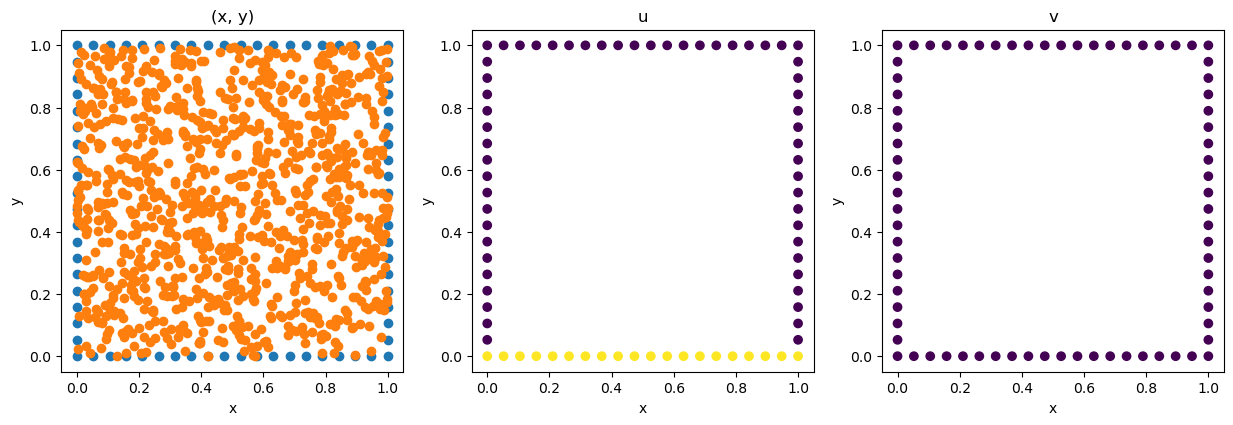

In [2]:
# YOUR CODE HERE (30pts)

# YOUR GENERATE TRAINING SET CODE HERE
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(1)


# Sampling domain points
N_bound = 20 # Number of smaple points at the boundary
N_bulk = 1000 # Number of smaple points in the bulk
r_bound = torch.zeros((4*N_bound-4, 2))
x = torch.linspace(0, 1, N_bound)
y = torch.linspace(0, 1, N_bound)

# y = 0
r_bound[:N_bound, 0] = x

# x = 1
r_bound[N_bound:2*N_bound-2, 0] = x[-1]
r_bound[N_bound:2*N_bound-2, 1] = y[1:-1]

# y = 1
r_bound[2*N_bound-2:3*N_bound-2, 0] = x
r_bound[2*N_bound-2:3*N_bound-2, 1] = y[-1]

# x = 0
r_bound[3*N_bound-2:4*N_bound-4, 1] = y[1:-1]

r_bound.requires_grad_(True)

# (x, y) in bulk
r_bulk = torch.rand((N_bulk, 2), requires_grad=True)

# Boundary condition for u, v
u_bound = torch.zeros((4*N_bound-4))
u_bound[:N_bound] = 1.0
v_bound = torch.zeros((4*N_bound-4))

plt.figure(figsize=(15, 45))

plt.subplot(1, 3, 1)
plt.scatter(r_bound[:, 0].detach(), r_bound[:, 1].detach())
plt.scatter(r_bulk[:, 0].detach(), r_bulk[:, 1].detach())
plt.title('(x, y)')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.subplot(1, 3, 2)
plt.scatter(r_bound[:, 0].detach(), r_bound[:, 1].detach(), c=u_bound)
plt.title('u')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.subplot(1, 3, 3)
plt.scatter(r_bound[:, 0].detach(), r_bound[:, 1].detach(), c=v_bound)
plt.title('v')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')

plt.show()

In [2]:
# YOUR CODE HERE (30pts)

# YOUR NEURAL NETWORK DESIGN AND LOSS WITH RESIDUAL CODE HERE
torch.manual_seed(1)
PINN_net = nn.Sequential(
    # input: x, y
    # output: psi, p
    # If we consider psi, u_x+v_y = psi_xy - psi_yx = 0. Therefore, we don't need to consider Eq. (1)
    nn.Linear(2, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 2)
    )


def Residual(net, r_b, r, u_b, v_b, nu):
    '''
    net: Neural newtork
    r_b: (x, y) for boundary 
    r: (x, y) for bulk
    u_b: Boundary condition for u
    v_b: Boundary condition for v
    nu: PDE parameter

    Approach: Differentiate psi first, and fit boundary condition using u and v
    '''
    
    # At the boundary
    out_b = net(r_b)
    psi_b = out_b[:, 0]
    p_b = out_b[:, 1]
    dpsi_b = torch.autograd.grad(psi_b, r_b, grad_outputs=torch.ones_like(psi_b), create_graph=True)[0]
    u_b_pred = dpsi_b[:, 1]
    v_b_pred = -dpsi_b[:, 0]

    loss_b = ((u_b_pred.squeeze() - u_b)**2).mean() + ((v_b_pred.squeeze() - v_b)**2).mean()

    loss_p = ((p_b[0])**2).mean() # Gauge fixing of pressure

    loss_psi = (psi_b[0]**2).mean() # Gauge fixing of psi

    # At the bulk
    out = net(r)
    psi = out[:, 0] 
    p = out[:, 1]

    dpsi = torch.autograd.grad(psi, r, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
    u = dpsi[:, 1]
    v = -dpsi[:, 0]

    du = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    ux = du[:, 0]
    uy = du[:, 1]
    uxx = torch.autograd.grad(ux, r, grad_outputs=torch.ones_like(ux), create_graph=True)[0][:, 0]
    uyy = torch.autograd.grad(uy, r, grad_outputs=torch.ones_like(uy), create_graph=True)[0][:, 1]

    dv = torch.autograd.grad(v, r, grad_outputs=torch.ones_like(v), create_graph=True)[0]
    vx = dv[:, 0]
    vy = dv[:, 1]
    vxx = torch.autograd.grad(vx, r, grad_outputs=torch.ones_like(vx), create_graph=True)[0][:, 0]
    vyy = torch.autograd.grad(vy, r, grad_outputs=torch.ones_like(vy), create_graph=True)[0][:, 1]

    dp = torch.autograd.grad(p, r, grad_outputs=torch.ones_like(p), create_graph=True)[0]
    px = dp[:, 0]
    py = dp[:, 1]


    loss_PDE = ((u*ux + v*uy + px - nu*(uxx + uyy))**2).mean() + ((u*vx + v*vy + py - nu*(vxx + vyy))**2).mean()
    # We don't need to care about ux + uy = 0 since we introduced psi.

    loss = loss_b + (1e-3)*loss_PDE + (1e-1)*loss_p + (1e-1)*loss_psi


    return loss

In [3]:
# YOUR CODE HERE (30pts)

# YOUR TRAINING NEURAL NETWORK CODE HERE
# TRAINING NEURAL NETWORK
epochs = 20000
loss_list = np.zeros(epochs, dtype=float)
optimizer = optim.Adam(PINN_net.parameters(), lr=1e-3)

for epoch in range(epochs):
    optimizer.zero_grad()
    loss = Residual(PINN_net, r_bound, r_bulk, u_bound, v_bound, 0.1)
    loss.backward()
    optimizer.step()
    loss_list[epoch] = loss.item()


    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")

Epoch 1000/20000, Loss: 0.007154474500566721
Epoch 2000/20000, Loss: 0.0048881154507398605
Epoch 3000/20000, Loss: 0.0035369584802538157
Epoch 4000/20000, Loss: 0.0014816304901614785
Epoch 5000/20000, Loss: 0.0009639119962230325
Epoch 6000/20000, Loss: 0.0006723949336446822
Epoch 7000/20000, Loss: 0.0011793700978159904
Epoch 8000/20000, Loss: 0.00033220896148122847
Epoch 9000/20000, Loss: 0.0002905000583268702
Epoch 10000/20000, Loss: 0.000189116588444449
Epoch 11000/20000, Loss: 0.0003948138910345733
Epoch 12000/20000, Loss: 0.00014055543579161167
Epoch 13000/20000, Loss: 0.0001143157496699132
Epoch 14000/20000, Loss: 0.00010095970355905592
Epoch 15000/20000, Loss: 0.00013650511391460896
Epoch 16000/20000, Loss: 8.373847958864644e-05
Epoch 17000/20000, Loss: 7.694863597862422e-05
Epoch 18000/20000, Loss: 7.037345494609326e-05
Epoch 19000/20000, Loss: 0.00011226688366150483
Epoch 20000/20000, Loss: 6.708770524710417e-05


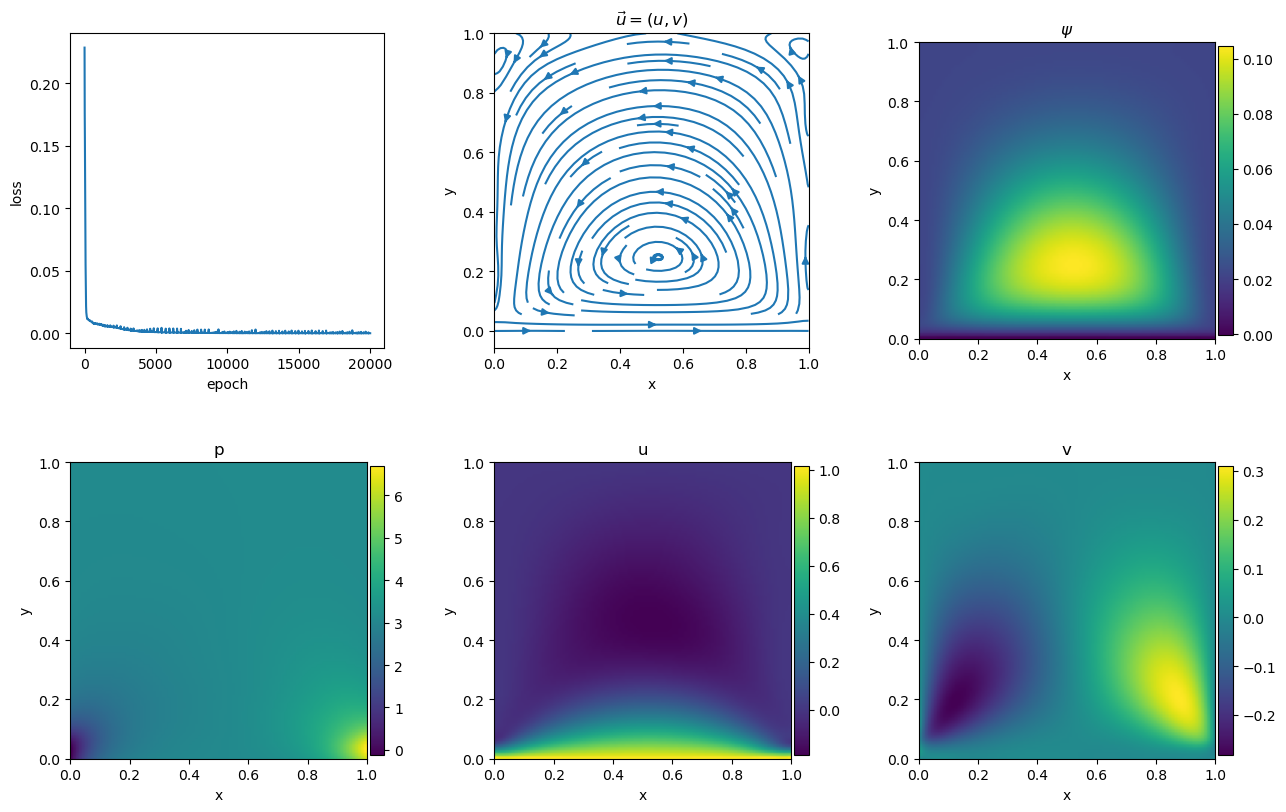

In [12]:
# VISUALIZATION (10pts)

# YOUR VISUALIZATION CODE HERE
PINN_net.eval()
x = torch.linspace(0, 1, 100)
y = torch.linspace(0, 1, 100)
X, Y = torch.meshgrid(x, y, indexing='xy')
r = torch.cat((X.reshape(-1, 1), Y.reshape(-1, 1)), dim=1)
r.requires_grad_(True)

out = PINN_net(r)
psi = out[:, 0]
p = out[:, 1]

dpsi = torch.autograd.grad(psi, r, grad_outputs=torch.ones_like(psi), create_graph=True)[0]
u = dpsi[:, 1]
v = -dpsi[:, 0]

du = torch.autograd.grad(u, r, grad_outputs=torch.ones_like(u), create_graph=True)[0]
ux = du[:, 0]

dv = torch.autograd.grad(v, r, grad_outputs=torch.ones_like(v), create_graph=True)[0]
vy = dv[:, 1]

u = u.detach().numpy().reshape(len(x), len(y))
v = v.detach().numpy().reshape(len(x), len(y))
ux = ux.detach().numpy().reshape(len(x), len(y))
vy = vy.detach().numpy().reshape(len(x), len(y))


psi = psi.detach().numpy().reshape(len(x), len(y))
p = p.detach().numpy().reshape(len(x), len(y))
X = X.detach().numpy().reshape(len(x), len(y))
Y = Y.detach().numpy().reshape(len(x), len(y))

fig = plt.figure(figsize=(15, 10))

ax1 = plt.subplot(231)
ax1.plot(loss_list)
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.set_box_aspect(True)

ax2 = plt.subplot(232)
ax2.set_title('$\\vec{u}=(u,v)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.streamplot(X, Y, u, v)
ax2.set_box_aspect(True)

ax3 = plt.subplot(233)
ax3.set_title('$\psi$')
ax3.set_xlabel('x')
ax3.set_ylabel('y')
im_psi = ax3.imshow(psi, extent=[0, 1, 0,1], origin='lower')
plt.colorbar(im_psi, ax=ax3, fraction=0.046, pad=0.01)

ax4 = plt.subplot(234)
ax4.set_title('p')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
im_p = ax4.imshow(p, extent=[0, 1, 0,1], origin='lower')
plt.colorbar(im_p, ax=ax4, fraction=0.046, pad=0.01)

ax5 = plt.subplot(235)
ax5.set_title('u')
ax5.set_xlabel('x')
ax5.set_ylabel('y')
im_u = ax5.imshow(u, extent=[0, 1, 0,1], origin='lower')
plt.colorbar(im_u, ax=ax5, fraction=0.046, pad=0.01)

ax6 = plt.subplot(236)
ax6.set_title('v')
ax6.set_xlabel('x')
ax6.set_ylabel('y')
im_v = ax6.imshow(v, extent=[0, 1, 0,1], origin='lower')
plt.colorbar(im_v, ax=ax6, fraction=0.046, pad=0.01)

plt.subplots_adjust(wspace=0.35)

plt.show()



======= |u| =======
minimum value=0.00010306302283424884
maximum value=1.0152409076690674
======= u_x + v_y =======
minimum value=-5.245208740234375e-06
maximum value=4.827976226806641e-06


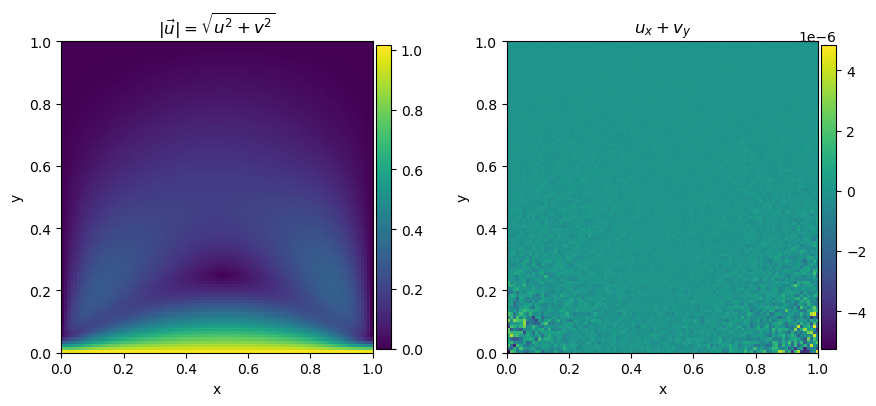

In [16]:
u_norm = np.sqrt(u**2 + v**2)
uxuy = ux + vy

print("======= |u| =======")
print(f"minimum value={np.min(u_norm)}")
print(f"maximum value={np.max(u_norm)}")
print("======= u_x + v_y =======")
print(f"minimum value={np.min(uxuy)}")
print(f"maximum value={np.max(uxuy)}")

fig = plt.figure(figsize=(10, 20))

ax7 = plt.subplot(121)
ax7.set_xlabel('x')
ax7.set_ylabel('y')
ax7.set_title('$|\\vec{u}|=\\sqrt{u^2+v^2}$')
im_norm = ax7.imshow(u_norm, extent=[0, 1, 0,1], origin='lower', vmin=0.0)
plt.colorbar(im_norm, ax=ax7, fraction=0.046, pad=0.01)

ax8 = plt.subplot(122)
ax8.set_xlabel('x')
ax8.set_ylabel('y')
ax8.set_title('$u_x+v_y$')
im_uxuy = ax8.imshow(uxuy, extent=[0, 1, 0, 1], origin='lower')
plt.colorbar(im_uxuy, ax=ax8, fraction=0.046, pad=0.01)

plt.subplots_adjust(wspace=0.35)

plt.show()